In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)

In [85]:
import glob
files = glob.glob("Scrapper/results/track_nodupe/*.csv")
df_list = []
for file in files:
    temp = pd.read_csv(file)
    year = file.split("_")[-1].split(".")[0] # Extract year from filename (e.g. track_ids_nd_2016.csv)
    temp["Year"] = int(year)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)
# Convert duration to seconds
df["Duration_sec"] = df["Duration (ms)"] / 1000
df.head()

,billboard_id,track_id,Track Name,Artist Name(s),Release Date,Duration (ms),Explicit,Genres,Danceability,Energy,...,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature,Year,Duration_sec
0,2016-01-001,1CkvWZme3pRgbzaxZnTl5X,rolling in the deep,adele,2011-01-19,228293,False,soft pop,0.729,0.756,...,1,0.0294,0.1310,0.000000,0.0527,0.522,104.945,4,2016,228.293
1,2016-01-002,6W2Ef5Ph6ILTUAedoQ3QIv,like i love you,justin timberlake,2002-11-04,283626,False,NaN,0.853,0.811,...,0,0.0646,0.0439,0.000307,0.0703,0.900,114.964,4,2016,283.626
2,2016-01-003,3QLjDkgLh9AOEHlhQtDuhs,best i ever had,drake,2009,257690,True,rap,0.395,0.922,...,1,0.3750,0.1900,0.000000,0.1340,0.558,162.361,4,2016,257.690
3,2016-01-006,0zt7g7yazz9SiWHprOVIHZ,naturally,selena gomez & the scene,2010-01-01,202560,False,NaN,0.605,0.907,...,0,0.0496,0.0164,0.000002,0.0533,0.871,132.617,4,2016,202.560
4,2016-01-007,4cebVIEpo3f2Pks50fATbc,sentimental me,the ames brothers,2007-05-26,198239,False,adult standards,0.410,0.177,...,1,0.0274,0.8600,0.000000,0.1180,0.264,75.601,4,2016,198.239


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1683 entries, 0 to 1682
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   billboard_id      1683 non-null   object 
 1   track_id          1683 non-null   object 
 2   Track Name        1683 non-null   object 
 3   Artist Name(s)    1683 non-null   object 
 4   Release Date      1683 non-null   object 
 5   Duration (ms)     1683 non-null   int64  
 6   Explicit          1683 non-null   bool   
 7   Genres            1122 non-null   object 
 8   Danceability      1683 non-null   float64
 9   Energy            1683 non-null   float64
 10  Loudness          1683 non-null   float64
 11  Mode              1683 non-null   int64  
 12  Speechiness       1683 non-null   float64
 13  Acousticness      1683 non-null   float64
 14  Instrumentalness  1683 non-null   float64
 15  Liveness          1683 non-null   float64
 16  Valence           1683 non-null   float64


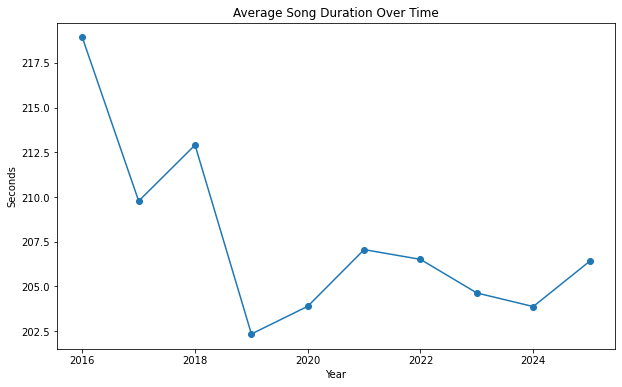

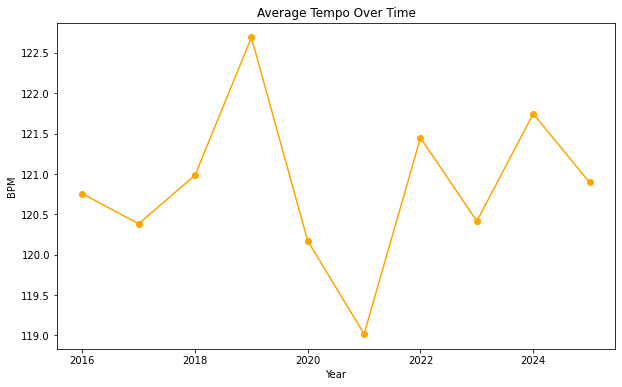

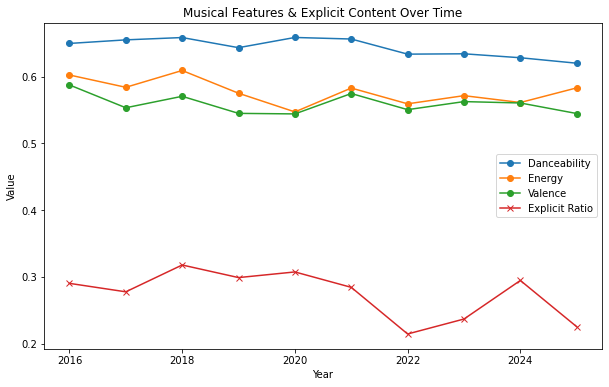

In [87]:
# duration_trend
duration_trend = df.groupby("Year")["Duration_sec"].mean()
duration_trend.plot(marker="o")
plt.title("Average Song Duration Over Time")
plt.ylabel("Seconds")
plt.savefig("Milestone1_src/Duration.png", facecolor="white")
plt.show()
# tempo
tempo_trend = df.groupby("Year")["Tempo"].mean()
tempo_trend.plot(marker="o", color="orange")
plt.title("Average Tempo Over Time")
plt.ylabel("BPM")
plt.savefig("Milestone1_src/Tempo.png", facecolor="white")
plt.show()
# Music features
features = ["Danceability", "Energy", "Valence"]
yearly = df.groupby("Year")[features + ["Explicit"]].mean()
fig = plt.figure()
for col in features:
    plt.plot(yearly.index, yearly[col], marker="o", label=col)
plt.plot(yearly.index, yearly["Explicit"], marker="x", label="Explicit Ratio")
plt.legend()
plt.title("Musical Features & Explicit Content Over Time")
plt.ylabel("Value")
plt.xlabel("Year")
plt.savefig("Milestone1_src/MusicFeatures.png", facecolor="white")
plt.show()

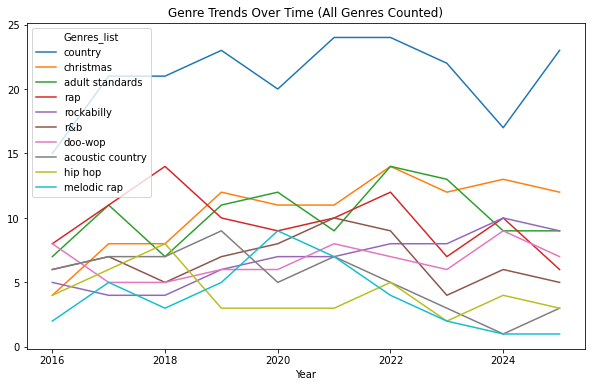

In [88]:
df["Genres_list"] = df["Genres"].str.split(",")
df_genres = df.explode("Genres_list")
df_genres["Genres_list"] = df_genres["Genres_list"].str.strip().str.lower()

top_genres = df_genres["Genres_list"].value_counts().head(10)
genre_year = df_genres.groupby(["Year", "Genres_list"]).size().unstack(fill_value=0)

genre_year[top_genres.index].plot()
plt.title("Genre Trends Over Time (All Genres Counted)")
plt.savefig("Milestone1_src/Genre.png", facecolor="white")
plt.show()

In [89]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = [
    "Danceability", "Energy", "Tempo", 
    "Valence", "Acousticness"
]

X = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)
df.loc[X.index, "Cluster"] = kmeans.fit_predict(X_scaled)

/opt/homebrew/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


No handles with labels found to put in legend.


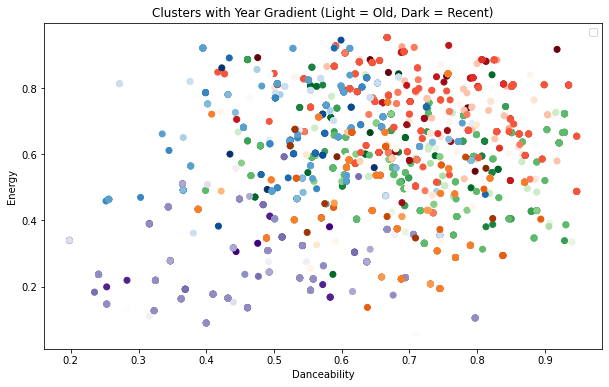

In [90]:
from matplotlib import cm
from matplotlib.colors import Normalize

norm = Normalize(vmin=df["Year"].min(), vmax=df["Year"].max())
cluster_cmaps = { 0: cm.Reds, 1: cm.Blues, 2: cm.Greens, 3: cm.Purples, 4: cm.Oranges }
plt.figure(figsize=(10, 6))

for cluster in df["Cluster"].unique():
    subset = df[df["Cluster"] == cluster]
    colors = cluster_cmaps[cluster](norm(subset["Year"]))
    plt.scatter(
        subset["Danceability"],
        subset["Energy"],
        c=colors,
        alpha=1
    )

plt.xlabel("Danceability") # "Danceability", "Energy", "Tempo", "Valence", "Acousticness"
plt.ylabel("Energy")       # "Danceability", "Energy", "Tempo", "Valence", "Acousticness"
plt.title("Clusters with Year Gradient (Light = Old, Dark = Recent)")
plt.legend()
plt.savefig("Milestone1_src/Clusters.png", facecolor="white")
plt.show()

/opt/homebrew/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/homebrew/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/homebrew/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/homebrew/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/homebrew/lib/python3.9/site-packages/sklearn/cluster/_k

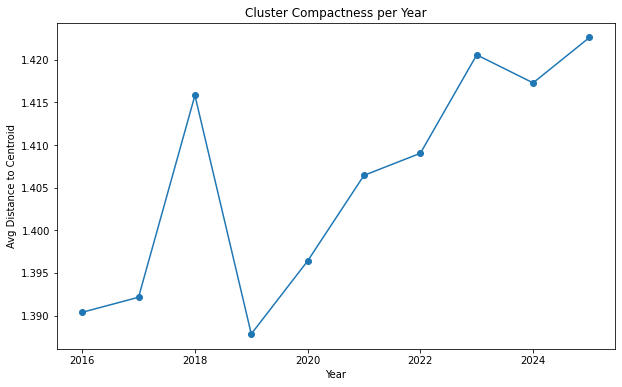

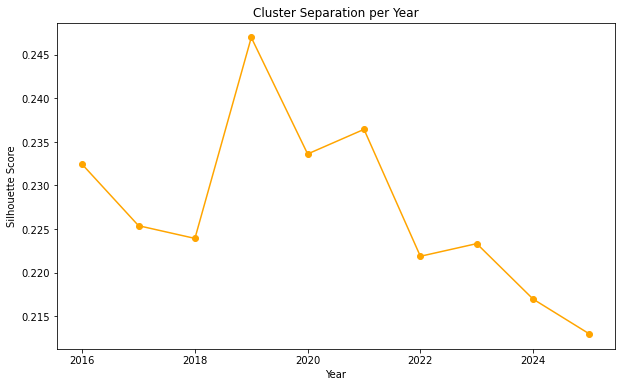

In [91]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

features = ["Danceability", "Energy", "Tempo", "Valence", "Acousticness"]

results = []

for year in sorted(df["Year"].unique()):
    subset = df[df["Year"] == year].dropna(subset=features)
    
    if len(subset) < 10:
        continue
    
    X = subset[features]
    
    # Scale per year
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Cluster
    kmeans = KMeans(n_clusters=5, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    # Distance to centroid
    distances = cdist(X_scaled, kmeans.cluster_centers_)
    dist_to_center = [distances[i, c] for i, c in enumerate(labels)]
    
    avg_distance = np.mean(dist_to_center)
    
    # Silhouette score
    sil = silhouette_score(X_scaled, labels)
    
    results.append({
        "Year": year,
        "Avg_Distance": avg_distance,
        "Silhouette": sil
    })

metrics_df = pd.DataFrame(results)

plt.plot(metrics_df["Year"], metrics_df["Avg_Distance"], marker="o")
plt.title("Cluster Compactness per Year")
plt.ylabel("Avg Distance to Centroid")
plt.xlabel("Year")
plt.savefig("Milestone1_src/Compactness.png", facecolor="white")
plt.show()

plt.plot(metrics_df["Year"], metrics_df["Silhouette"], marker="o", color="orange")
plt.title("Cluster Separation per Year")
plt.ylabel("Silhouette Score")
plt.xlabel("Year")
plt.savefig("Milestone1_src/Silhouette.png", facecolor="white")
plt.show()

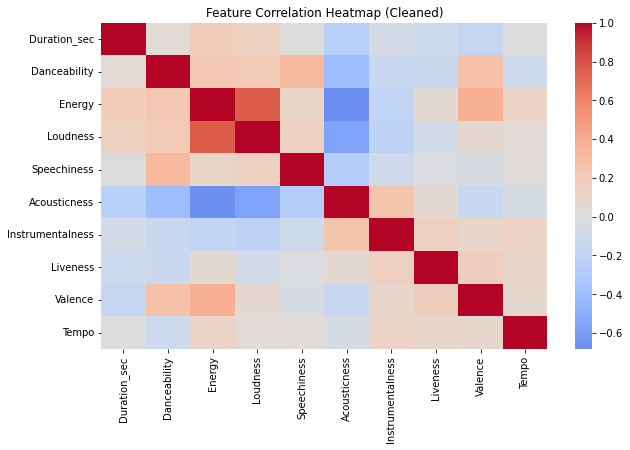

In [92]:
features = [
    "Duration_sec",
    "Danceability", "Energy", "Loudness", "Speechiness",
    "Acousticness", "Instrumentalness", "Liveness",
    "Valence", "Tempo"
]

corr = df[features].corr()

import seaborn as sns
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap (Cleaned)")
plt.savefig("Milestone1_src/Heatmap.png", facecolor="white")
plt.show()